In [1]:
#1
import geopandas as gpd
import os

folder = r"C:\Users\aparn\MTech26\Lab_5"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".shp"):

            path = os.path.join(root, file)

            gdf = gpd.read_file(path)

            print("Shapefile:", file)
            print("Projection:", gdf.crs)
            print("-----------------------------")

Shapefile: meghalaya.shp
Projection: EPSG:3857
-----------------------------
Shapefile: NE_states.shp
Projection: EPSG:3857
-----------------------------


In [ ]:
#2
import geopandas as gpd
import os

folder = r"C:\Users\aparn\MTech26\Lab_5"

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith(".shp"):

            path = os.path.join(root, file)
            gdf = gpd.read_file(path)

            attributes = gdf.drop(columns="geometry")

            null_count = attributes.isnull().sum()

            print("\nShapefile:", file)
            print("Number of features:", len(gdf))
            print("\nNull entries in each attribute:")

            for column in attributes.columns:
                print(column, ":", null_count[column])

            total_nulls = null_count.sum()

            print("\nTotal null entries:", total_nulls)

            if total_nulls == 0:
                print("Status: No missing attributes")
            else:
                print("Status: Missing attributes found")

            print("-" * 50)



Shapefile: meghalaya.shp
Number of features: 1

Null entries in each attribute:
State_Name : 0

Total null entries: 0
Status: No missing attributes
--------------------------------------------------

Shapefile: NE_states.shp
Number of features: 7

Null entries in each attribute:
State_Name : 0

Total null entries: 0
Status: No missing attributes
--------------------------------------------------



Shapefile: meghalaya.shp
Original CRS: EPSG:3857
New CRS: EPSG:4326
Saved: C:\Users\aparn\MTech26\Lab_5\reprojected_EPSG4326\meghalaya_EPSG4326.shp

Shapefile: NE_states.shp
Original CRS: EPSG:3857
New CRS: EPSG:4326
Saved: C:\Users\aparn\MTech26\Lab_5\reprojected_EPSG4326\NE_states_EPSG4326.shp


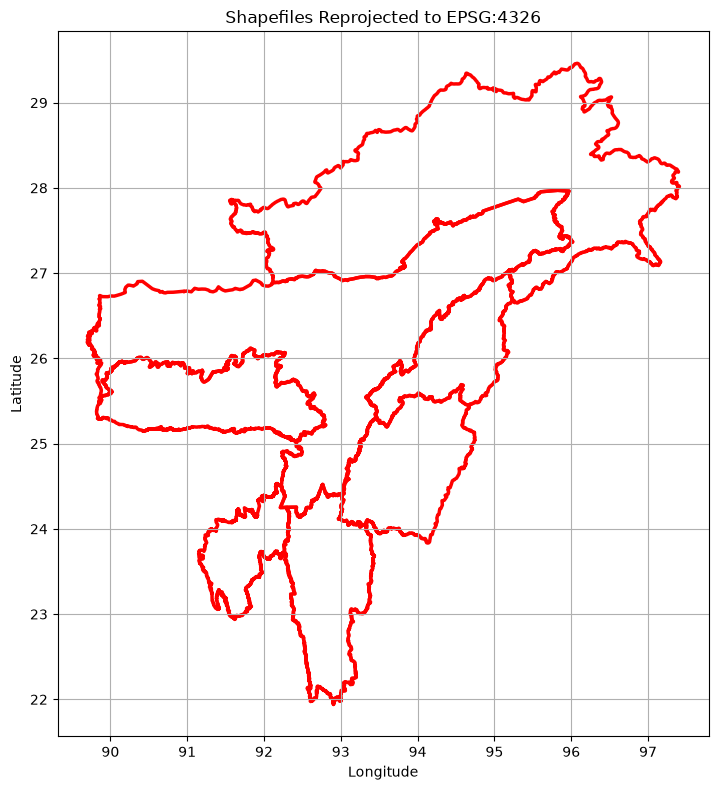

In [ ]:
#3
import geopandas as gpd
import matplotlib.pyplot as plt
import os

input_folder = r"C:\Users\aparn\MTech26\Lab_5"
output_folder = os.path.join(input_folder, "reprojected_EPSG4326")

os.makedirs(output_folder, exist_ok=True)

for root, dirs, files in os.walk(input_folder):

    dirs[:] = [d for d in dirs if d != "reprojected_EPSG4326"]

    for file in files:

        if file.lower().endswith(".shp"):

            input_path = os.path.join(root, file)

            gdf = gpd.read_file(input_path)

            print("\nShapefile:", file)
            print("Original CRS:", gdf.crs)

            gdf_4326 = gdf.to_crs(epsg=4326)

            print("New CRS:", gdf_4326.crs)

            output_name = os.path.splitext(file)[0] + "_EPSG4326.shp"
            output_path = os.path.join(output_folder, output_name)

            gdf_4326.to_file(output_path)

            print("Saved:", output_path)

fig, ax = plt.subplots(figsize=(8, 8))

for file in os.listdir(output_folder):

    if file.lower().endswith(".shp"):

        path = os.path.join(output_folder, file)

        gdf = gpd.read_file(path)

        if "NE_states" in file:

            gdf.plot(
                ax=ax,
                facecolor="none",
                edgecolor="red",
                linewidth=2.5
            )

        else:

            gdf.plot(
                ax=ax,
                facecolor="none",
                edgecolor="black",
                linewidth=1
            )

ax.set_title("Shapefiles Reprojected to EPSG:4326")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.grid(True)
plt.tight_layout()
plt.show()

Original CRS: EPSG:3857
Number of features: 7

Features included:
['Assam', 'Arunachal Pradesh', 'Nagaland', 'Manipur', 'Mizoram', 'Tripura', 'Meghalaya']

North Eastern State Areas:
       State_Name     Area_km2
Arunachal Pradesh 82045.708373
            Assam 78437.556144
        Meghalaya 22418.106934
          Manipur 22309.642886
          Mizoram 21065.766738
         Nagaland 16586.223593
          Tripura 10444.246300


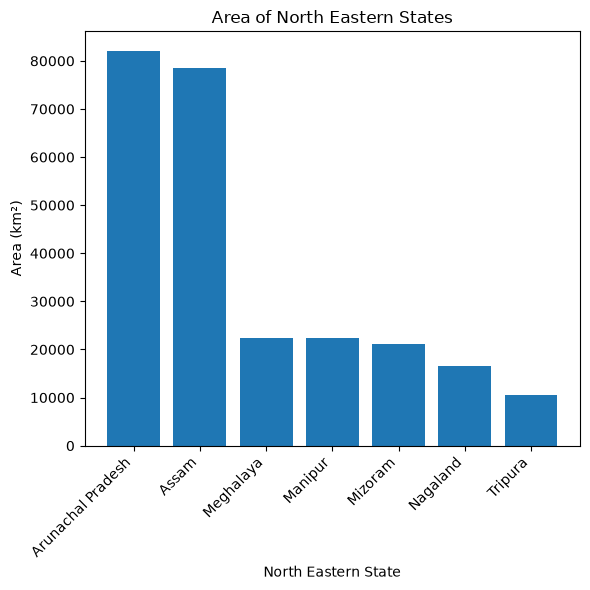

In [ ]:
#4
import geopandas as gpd
import matplotlib.pyplot as plt
import os

input_path = r"C:\Users\aparn\MTech26\Lab_5\NE_states\NE_states.shp"

gdf = gpd.read_file(input_path)

print("Original CRS:", gdf.crs)
print("Number of features:", len(gdf))

print("\nFeatures included:")
print(gdf["State_Name"].tolist())

gdf_area = gdf.to_crs(epsg=32646)

gdf["Area_km2"] = (
    gdf_area.geometry.area / 1_000_000
)

gdf_sorted = gdf.sort_values(
    by="Area_km2",
    ascending=False
)

print("\nNorth Eastern State Areas:")
print(
    gdf_sorted[["State_Name", "Area_km2"]].to_string(
        index=False
    )
)

plt.figure(figsize=(6, 6))

plt.bar(
    gdf_sorted["State_Name"],
    gdf_sorted["Area_km2"]
)

plt.xlabel("North Eastern State")
plt.ylabel("Area (km²)")
plt.title("Area of North Eastern States")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

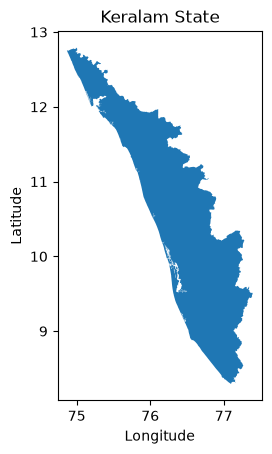

In [12]:
#5
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file(r"C:\Users\aparn\MTech26\Lab_5\gadm41_IND_shp\gadm41_IND_1.shp")

kerala = gdf[gdf["NAME_1"] == "Kerala"]

kerala.plot()

plt.title("Keralam State")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Chandigarh CRS: EPSG:4326
Saved to: C:\Users\aparn\MTech26\Chandigarh_EPSG4326.shp


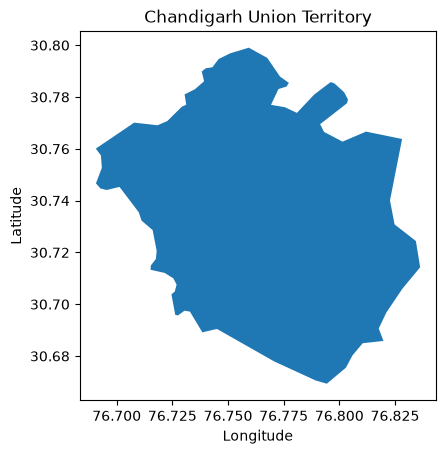

In [ ]:
#6
import geopandas as gpd

input_path = r"C:\Users\aparn\MTech26\Lab_5\gadm41_IND_shp\gadm41_IND_1.shp"

gdf = gpd.read_file(input_path)

Chandigarh = gdf[gdf["NAME_1"] == "Chandigarh"].copy()

Chandigarh_4326 = Chandigarh.to_crs(epsg=4326)

output_path = r"C:\Users\aparn\MTech26\Chandigarh_EPSG4326.shp"

Chandigarh_4326.to_file(output_path)

print("Chandigarh CRS:", Chandigarh_4326.crs)
print("Saved to:", output_path)

Chandigarh.plot()

plt.title("Chandigarh Union Territory")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

                 NAME_2     Area_km2
283              Idukki  4992.051351
290            Palakkad  4471.545777
289          Malappuram  3498.519565
293            Thrissur  2939.998337
284              Kannur  2771.957817
291      Pathanamthitta  2635.051163
286              Kollam  2404.962664
288           Kozhikode  2270.668452
282           Ernakulam  2249.677913
294             Wayanad  2121.009810
287            Kottayam  2102.653919
292  Thiruvananthapuram  2043.362733
285           Kasaragod  1949.547662
281           Alappuzha  1245.132248


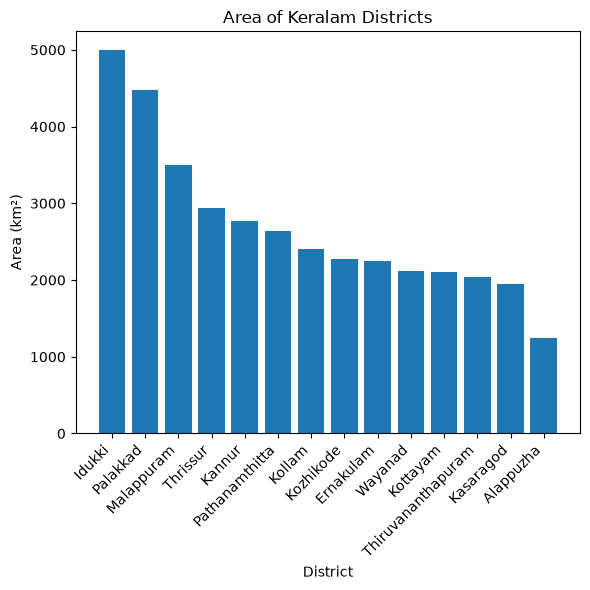

In [ ]:
#7
import geopandas as gpd
import matplotlib.pyplot as plt

input_path = r"C:\Users\aparn\MTech26\Lab_5\gadm41_IND_shp\gadm41_IND_2.shp"

gdf = gpd.read_file(input_path)

kerala = gdf[gdf["NAME_1"] == "Kerala"].copy()

kerala_area = kerala.to_crs(epsg=32643)

kerala["Area_km2"] = kerala_area.geometry.area / 1_000_000

kerala = kerala.sort_values(
    by="Area_km2",
    ascending=False
)

print(kerala[["NAME_2", "Area_km2"]])

plt.figure(figsize=(6, 6))

plt.bar(
    kerala["NAME_2"],
    kerala["Area_km2"]
)

plt.xlabel("District")
plt.ylabel("Area (km²)")
plt.title("Area of Keralam Districts")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()